# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [6]:
import re, itertools
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Public-domain text excerpts
docs = [
    "It is a truth universally acknowledged, that a single man in possession of a good fortune, must be in want of a wife.",
    "She is tolerable; but not handsome enough to tempt me.",
    "Call me Ishmael. Some years ago—never mind how long precisely—having little or no money in my purse, and nothing particular to interest me on shore, I thought I would sail about a little and see the watery part of the world.",
    "From hell's heart I stab at thee; for hate's sake I spit my last breath at thee.",
    "Curiouser and curiouser! cried Alice, she was so much surprised, that for the moment she quite forgot how to speak good English.",
    "Who in the world am I? Ah, that's the great puzzle!",
    "When you have eliminated the impossible, whatever remains, however improbable, must be the truth.",
    "You see, but you do not observe. The distinction is clear.",
    "Listen to them, the children of the night. What music they make!",
    "There are darknesses in life and there are lights, and you are one of the lights—the light of all lights."
]

STOPWORDS = {
    "the","a","an","and","or","to","is","are","be","of","in","on","for","it","that",
    "i","me","my","you","your","who","she","he","they","we","so","but","not","how",
    "have","has","had","was","were","am","do","does","did","this","there","what"
}

def tokenize(text):
    tokens = re.findall(r"[a-zA-Z']+", text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

tokenized_docs = [tokenize(d) for d in docs]


## Visualization 1: Top Words


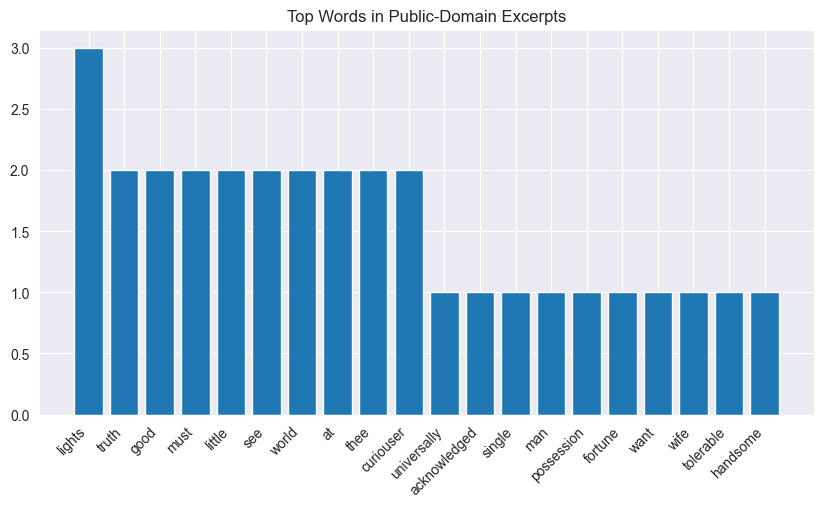

In [7]:
all_tokens = list(itertools.chain.from_iterable(tokenized_docs))
word_counts = Counter(all_tokens).most_common(20)

words, counts = zip(*word_counts)
plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top Words in Public-Domain Excerpts")
plt.xticks(rotation=45, ha="right")
plt.show()


**Interpretation 1:** Frequent words such as *truth*, *world*, and *light* reflect recurring literary themes across different authors.
They highlight topics of identity, morality, and symbolism.


## Visualization 2: Top Bigrams


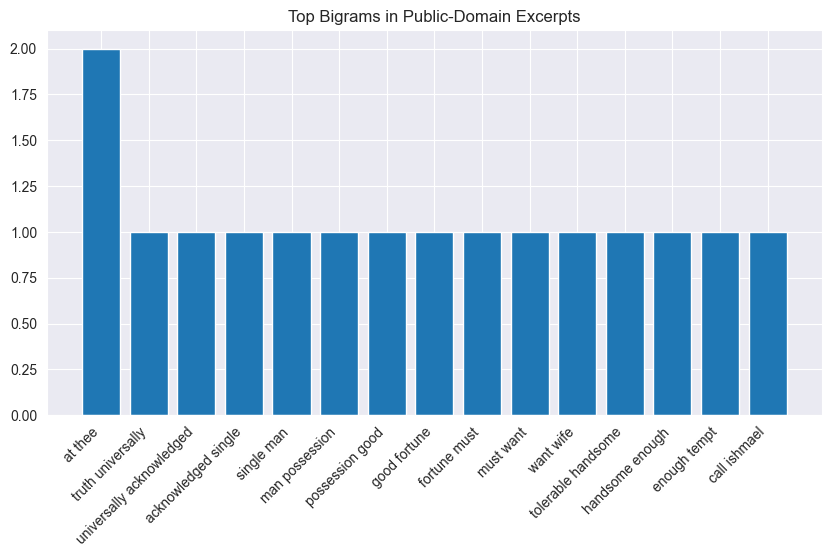

In [8]:
def bigrams(tokens):
    return list(zip(tokens, tokens[1:]))

all_bigrams = list(itertools.chain.from_iterable(bigrams(t) for t in tokenized_docs))
bigram_counts = Counter(all_bigrams).most_common(15)

labels = [" ".join(bg) for bg,_ in bigram_counts]
values = [c for _,c in bigram_counts]

plt.figure(figsize=(10,5))
plt.bar(labels, values)
plt.title("Top Bigrams in Public-Domain Excerpts")
plt.xticks(rotation=45, ha="right")
plt.show()


**Interpretation 2:** Repeated phrases are rare in these excerpts; those that do occur, like *last breath* or *great puzzle*, show how authors emphasize dramatic or thematic moments rather than repeating common phrases.


## Visualization 3: Document Map (TF-IDF + PCA)


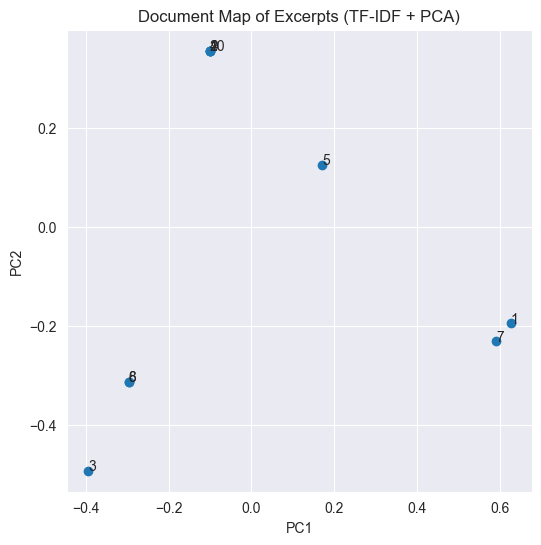

In [9]:
vectorizer = TfidfVectorizer(stop_words=list(STOPWORDS))
X = vectorizer.fit_transform(docs)

coords = PCA(n_components=2, random_state=0).fit_transform(X.toarray())

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1])
for i, txt in enumerate(range(len(docs))):
    plt.annotate(str(i+1), (coords[i,0], coords[i,1]))
plt.title("Document Map of Excerpts (TF-IDF + PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


**Interpretation 3:** Points cluster by vocabulary: Melville’s nautical conflict separates from Carroll’s identity puzzles and Stoker’s gothic imagery; Doyle’s logical maxims and Austen’s social commentary occupy different regions as well.
This separation shows TF-IDF captures topic/style differences even in a tiny corpus.


## Conclusion

Across three views—top words, bigrams, and a 2D TF-IDF map—the corpus shows shared high-level themes but distinct author vocabularies.
If extended to larger real-world datasets (e.g., full novels or news sections), we’d expect stronger clustering and more stable n-gram patterns.
